# Preciction of the AMOC with VIKING20X

This notebook performs the same experiment as `06_argo_prediction` but with the simulation data.

Hypothesis: If this works with simulation data the fault is the noise in the argo data. 



In [1]:
"""

What do I need for the calculation?

- dv_dz_obs from the simulation
- ds_argo_merged_10days from simulated argos
- t_umo_10days as a ground truth

"""

import xarray as xr
from pathlib import Path

deep_argo = True

smoothing_days = 30

time_smoothing = f'{smoothing_days}D'
consecutive_argo_windows = 1
phi = 7 # Number of observations that have to be in each 10D window.

dataset_path = Path(f'../rapid-geostrophic-reconstruction/datasets/smoothing_{smoothing_days}_days/argo_after_2012')

cycle_number = 1
dask_url = 'tcp://10.0.4.110:8786'

if cycle_number == 1:
    suffix = '1st_7020' 
    model = 'VIKING20X.L46-KFS003'
    model_years_selector = (1970, 2020)
elif cycle_number == 2:
    suffix = '2nd_5820'
    model = 'VIKING20X.L46-KFS003-2nd'
    model_years_selector = (1958, 2020)
elif cycle_number == 3:
    suffix = '3rd_5820'
    model = 'VIKING20X.L46-KFS003-3rd'
    model_years_selector = (1958, 2020)
elif cycle_number == 4:
    suffix = '4th_5820'
    model = 'VIKING20X.L46-KFS003-4th'
    model_years_selector = (1958, 2020)
elif cycle_number == 5:
    suffix = '5th_5820'
    model = 'VIKING20X.L46-KFS003-5th'
    model_years_selector = (1958, 2020)
elif cycle_number == 6:
    suffix = '6th_5820'
    model = 'VIKING20X.L46-KFS003-6th'
    model_years_selector = (1958, 2020)
else:
    assert False, 'Cycle number not recognized'

argo_time_slice = slice('01-01-2012', None)

dataset_sample_name = 'paperdraft'


if not (dataset_path / dataset_sample_name).exists():
    (dataset_path / dataset_sample_name).mkdir(parents=True)


time_mapping_file = dataset_path / dataset_sample_name / f'time_mapping_dict_{suffix}.pickle'

In [127]:
from dask.distributed import Client
client = Client(dask_url)
client

<Client: 'tcp://10.0.4.110:8786' processes=399 threads=399, memory=4.35 TiB>

In [2]:
from pathlib import Path
from xarray import open_mfdataset, open_dataset
def find_grid_files(grid_type, years, nest, model, delta_t, folder = 'output'): 
    experiment_path = Path('/gxfs_work/geomar/smomw355/model_data/ocean-only/')
    nest_part = '1_' if nest else '' 

    if len(grid_type) < 2:
        grid_type = f'grid_{grid_type}'

    grid_files = (experiment_path / model / 'nemo' / folder).glob(f'{nest_part}{model}_{delta_t}_*_*_{grid_type}.nc')
    grid_files = list(grid_files)
    
    result_files = []
    for file in grid_files:
        start_year = int(str(file).split('/')[-1].split('_')[- (3 + grid_type.count('_'))][:4])
        
        if (years[0] is None or start_year >= years[0]) and \
           (years[1] is None or start_year < years[1]):
            result_files.append(file)
    
    return sorted(result_files)

def load_dataset_from_grid_type(grid_type, years, nest, model, delta_t, chunks = {"time_counter" : 2,"y": 2, "x": None}, **kwargs):
    files_list = find_grid_files(grid_type, years, nest, model, delta_t, **kwargs)
    grid = open_mfdataset(
        files_list, # type: ignore
        chunks= chunks,
        combine='by_coords'
    )
    return grid

def load_masks(nest, model):

    if str.startswith(model, 'VIKING20X.L46-KFS003'):
        # All the mask for the long runs VIKING20X.L46-KFS003-2nd, ... are placed in the original experiment
        model = 'VIKING20X.L46-KFS003' 
    
    nest_part = '1_' if nest else ''
    
    mask_mesh = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}mesh_mask.nc',
        decode_cf=False,
        chunks={'y': 512, 'x':512},
    )
    mask_glo = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}new_maskglo.nc',
        decode_cf=False,
        chunks={'Y':512, 'X':512}
    )

    mask_mesh = mask_mesh.squeeze()
    mask_glo = mask_glo.rename({'X':'x', 'Y':'y'}).squeeze() # Rename coordinates to have the same name as the data file
    
    return mask_mesh, mask_glo

In [8]:

## Create a dictionary that maps from the simulation time data to the observation time within th goal to keep time windows of the size `time_smoothing` as one block

# Load the data
T = load_dataset_from_grid_type('T', model_years_selector, True, model, '1d', chunks = {"time_counter" : 1,"y": None, "x": None})
T

<xarray.Dataset>
Dimensions:               (y: 2499, x: 2404, deptht: 46, time_counter: 792,
                           axis_nbounds: 2)
Coordinates:
    nav_lat               (y, x) float32 dask.array<chunksize=(2499, 2404), meta=np.ndarray>
    nav_lon               (y, x) float32 dask.array<chunksize=(2499, 2404), meta=np.ndarray>
  * deptht                (deptht) float32 3.047 9.454 ... 5.625e+03 5.875e+03
    time_centered         (time_counter) datetime64[ns] dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter          (time_counter) datetime64[ns] 1958-01-16T12:00:00 ....
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/18)
    deptht_bounds         (time_counter, deptht, axis_nbounds) float32 dask.array<chunksize=(12, 46, 2), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    votemper              (time_counter, deptht, y, x) float32 dask.array<chunksize=(1, 46, 2499, 2404), meta=np.ndarray>
    vosaline              (time_counter, deptht, y, x) float32 dask.array<chunksize=(1, 46, 2499, 2404), meta=np.ndarray>
    sosstsst              (time_counter, y, x) float32 dask.array<chunksize=(1, 2499, 2404), meta=np.ndarray>
    ...                    ...
    sohefldo              (time_counter, y, x) float32 dask.array<chunksize=(1, 2499, 2404), meta=np.ndarray>
    somixhgt              (time_counter, y, x) float32 dask.array<chunksize=(1, 2499, 2404), meta=np.ndarray>
    sowindsp              (time_counter, y, x) float32 dask.array<chunksize=(1, 2499, 2404), meta=np.ndarray>
    sohefldp              (time_counter, y, x) float32 dask.array<chunksize=(1, 2499, 2404), meta=np.ndarray>
    sowafldp              (time_counter, y, x) float32 dask.array<chunksize=(1, 2499, 2404), meta=np.ndarray>
    sobowlin              (time_counter, y, x) float32 dask.array<chunksize=(1, 2499, 2404), meta=np.ndarray>
Attributes:
    name:         /p/scratch/viking/schwarzkopf1/VIKING20X.L46/VIKING20X.L46-...
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2020-Dec-09 15:21:46 GMT
    uuid:         3474e11c-2e72-48fc-9ff2-93332382f9a5
    history:      Mon Dec 21 12:10:23 2020: ncrcat 1_VIKING20X.L46-KFS003_1m_...
    NCO:          netCDF Operators version 4.9.6 (Homepage = http://nco.sf.ne...

In [3]:
obs_argo_array = xr.open_dataset(dataset_path / '../../ds_argo_obs_daily.nc')
obs_argo_array

<xarray.Dataset>
Dimensions:       (time: 7237, z: 242, pos: 20)
Coordinates:
  * time          (time) datetime64[ns] 2001-06-06 2001-06-16 ... 2023-08-06
  * z             (z) float64 -0.0 -20.0 -40.0 ... -4.78e+03 -4.8e+03 -4.82e+03
    pressure      (z) float64 ...
    lon           (time, pos) float64 ...
    lat           (time, pos) float64 ...
    time_1d       (time, pos) datetime64[ns] ...
  * pos           (pos) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
Data variables:
    temperature   (time, z, pos) float64 ...
    salinity      (time, z, pos) float64 ...
    profile_mask  (time, pos) float64 ...
    ct            (time, z, pos) float64 ...
    rho           (time, z, pos) float64 ...

In [4]:
mooring_data = xr.open_dataset(dataset_path / "../../ts_gridded.nc")

time_max = min(obs_argo_array.time.max(), mooring_data.time.max())
time_min = max(obs_argo_array.time.min(), mooring_data.time.min())

obs_argo_array = obs_argo_array.sel(time = slice(time_min, time_max))

In [5]:
time_min, time_max

(<xarray.DataArray 'time' ()>
 array('2004-04-02T00:00:00.000000000', dtype='datetime64[ns]'),
 <xarray.DataArray 'time' ()>
 array('2022-02-15T00:00:00.000000000', dtype='datetime64[ns]'))

In [6]:
# here the merging is hapenning
import numpy as np
import pandas as pd


"""
Back when we only had the original Argo in 10 day splits and used this code to transform them to 90days sections
"""
# max_profiles_per_time_smooting_unit = obs_argo_array.profile_mask.resample(time=time_smoothing).sum().sum('pos').max().values[()]

# def group_profiles(dataset):
    
#     reference_time = dataset.time.dt.round(time_smoothing).isel(time = 0).values[()]

#     smoothed = dataset.stack(pos_2 = ['time', 'pos'])
#     smoothed['time_1d'] = smoothed.time_1d.astype('datetime64[ns]')
#     smoothed = smoothed.where(smoothed.profile_mask > 0 , drop = True).drop_vars(['time', 'pos', 'pos_2']).rename({'pos_2': 'pos'}).expand_dims({'time': [reference_time]})
#     smoothed = smoothed.pad(pos = (0, int(max_profiles_per_time_smooting_unit)- smoothed.pos.shape[0])).assign_coords({'pos': np.arange(int(max_profiles_per_time_smooting_unit))})

#     # smoothed['time_1d'] = smoothed.time_1d.fillna(smoothed.time_1d.isel(pos = 0))

#     return smoothed

# grouped_array_of_argos = obs_argo_array.resample(time=time_smoothing).apply(group_profiles).assign_coords({'time': obs_argo_array.time.resample(time=time_smoothing).mean()}).isel(time = (obs_argo_array.profile_mask.sum('pos') > phi).resample(time = time_smoothing).all().values)

grouped_array_of_argos = obs_argo_array

In [9]:
import numpy as np
import pickle

if time_mapping_file.exists():

    with open(time_mapping_file, 'rb') as handle:
        time_mapping_dict = pickle.load( handle)
        print('Loaded')

else:

    single_frequency = True

    if single_frequency:
        list_of_fine_days_timesteps = np.unique(T.time_counter.dt.round(time_smoothing))

        list_of_argo_three_month_timesteps = grouped_array_of_argos.time.sel(time = argo_time_slice)
        list_of_argo_three_month_timesteps = list_of_argo_three_month_timesteps.where((list_of_argo_three_month_timesteps + pd.Timedelta(time_smoothing) / 2 <= time_max) & (list_of_argo_three_month_timesteps - pd.Timedelta(time_smoothing) / 2 >= time_min), drop = True)


        random_indices = np.random.choice(np.arange(len(list_of_argo_three_month_timesteps)), len(list_of_fine_days_timesteps), replace = True)


        time_mapping_dict = dict(zip(list_of_fine_days_timesteps, list_of_argo_three_month_timesteps.values[random_indices]))
    else:
        list_of_model_three_month_timesteps = np.unique(T.time_counter.dt.round('90D'))

        list_of_fine_days_timesteps = np.unique(T.time_counter.dt.round('10D'))

        list_of_argo_timesteps = grouped_array_of_argos.time.sel(time = argo_time_slice)
        list_of_argo_timesteps = list_of_argo_timesteps.where((list_of_argo_timesteps + pd.Timedelta('90D') / 2 <= time_max) & (list_of_argo_timesteps - pd.Timedelta('90D') / 2 >= time_min), drop = True)

        coarse_list_of_argo_timesteps = list_of_argo_timesteps.groupby(list_of_argo_timesteps.time.dt.floor('90D')).mean()


        random_indices = np.random.choice(np.arange(len(list_of_argo_timesteps)), len(list_of_model_three_month_timesteps), replace = True)

        time_mapping_dict = dict(zip(list_of_model_three_month_timesteps, list_of_argo_timesteps.values[random_indices]))

        ten_days_model = T.time_counter.dt.round('10D').groupby(T.time_counter.dt.round('10D')).first()
        rounded_ninety_days_model = ten_days_model.dt.round('90D')

        time_mapping_dict_fine = {}

        for fine_time_model, coarse_time_model in zip(ten_days_model, rounded_ninety_days_model):

            coarse_time_obs = time_mapping_dict[coarse_time_model.values[()]]


            delta_model = fine_time_model - coarse_time_model

            fine_time_obs = coarse_time_obs + delta_model

            assert fine_time_obs.values[()] in grouped_array_of_argos.time.values, f"{fine_time_obs.values[()]} not in list_of argo timesteps"

            time_mapping_dict_fine[fine_time_model.values[()]] = fine_time_obs.values[()]

                
        time_mapping_dict = time_mapping_dict_fine

    with open(time_mapping_file, 'wb') as handle:
        pickle.dump(time_mapping_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)
        print('Saved')

Saved


In [10]:
time_mapping_dict

{numpy.datetime64('1970-01-01T00:00:00.000000000'): numpy.datetime64('2013-07-14T00:00:00.000000000'),
 numpy.datetime64('1970-01-31T00:00:00.000000000'): numpy.datetime64('2021-12-29T00:00:00.000000000'),
 numpy.datetime64('1970-03-02T00:00:00.000000000'): numpy.datetime64('2016-03-30T00:00:00.000000000'),
 numpy.datetime64('1970-04-01T00:00:00.000000000'): numpy.datetime64('2014-07-09T00:00:00.000000000'),
 numpy.datetime64('1970-05-01T00:00:00.000000000'): numpy.datetime64('2016-05-29T00:00:00.000000000'),
 numpy.datetime64('1970-05-31T00:00:00.000000000'): numpy.datetime64('2017-04-24T00:00:00.000000000'),
 numpy.datetime64('1970-06-30T00:00:00.000000000'): numpy.datetime64('2013-05-15T00:00:00.000000000'),
 numpy.datetime64('1970-07-30T00:00:00.000000000'): numpy.datetime64('2015-06-04T00:00:00.000000000'),
 numpy.datetime64('1970-08-29T00:00:00.000000000'): numpy.datetime64('2017-02-23T00:00:00.000000000'),
 numpy.datetime64('1970-09-28T00:00:00.000000000'): numpy.datetime64('201

In [11]:
first_nan_index = np.isnan(grouped_array_of_argos.temperature).argmax('z') 

depth = grouped_array_of_argos.z.isel(z = (first_nan_index - 1)).where(first_nan_index > 0).rename('depth') 

grouped_array_of_argos = grouped_array_of_argos.assign_coords({'depth': depth, 'z': grouped_array_of_argos.z})
grouped_array_of_argos

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


<xarray.Dataset>
Dimensions:       (time: 218, z: 242, pos: 259)
Coordinates:
  * time          (time) datetime64[ns] 2004-04-02 2004-05-02 ... 2022-01-28
  * z             (z) float64 -0.0 -20.0 -40.0 ... -4.78e+03 -4.8e+03 -4.82e+03
    pressure      (z) float64 ...
    lon           (time, pos) float64 -68.15 -68.64 -68.85 ... nan nan nan
    lat           (time, pos) float64 26.78 27.5 28.21 28.79 ... nan nan nan nan
    time_1d       (time, pos) datetime64[ns] 2004-03-22 ... 2231-01-19T18:40:...
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 252 253 254 255 256 257 258
    depth         (time, pos) float64 -1.04e+03 -1.04e+03 -1.04e+03 ... nan nan
Data variables:
    temperature   (time, z, pos) float64 22.38 22.11 22.2 20.37 ... nan nan nan
    salinity      (time, z, pos) float64 ...
    profile_mask  (time, pos) float64 ...
    ct            (time, z, pos) float64 ...
    rho           (time, z, pos) float64 ...

In [42]:
import pandas as pd
argo_frame = None 

max_model_time = T.time_counter.max().values[()]



for timestep in list(time_mapping_dict.keys()):
    if type(timestep) == xr.DataArray:
        timestep = timestep.values[()]

    if timestep + (pd.to_timedelta(time_smoothing) / 2) > T.time_counter.max().values[()] or\
        timestep - (pd.to_timedelta(time_smoothing) / 2) < T.time_counter.min().values[()]:
        continue
    # df = grouped_array_of_argos.sel(time = time_mapping_dict[timestep]).isel(z = 0).to_dataframe()
    # df['days_offset'] = (df.time_1d.where(df.profile_mask > 0) - df.time.where(df.profile_mask > 0)).dt.days

    df = grouped_array_of_argos.sel(time = slice(
        time_mapping_dict[timestep] - (pd.to_timedelta(time_smoothing) / 2),
        time_mapping_dict[timestep] + (pd.to_timedelta(time_smoothing) / 2)
    )).stack(pos_2 = ['time', 'pos']).isel(z = 0).to_dataframe().reset_index(drop = True)

    df['days_offset'] = (df.time_1d.where(df.profile_mask > 0) - time_mapping_dict[timestep]).dt.days

    df['time_sim'] = timestep
    df['time_1d_sim'] = df.time_sim + pd.to_timedelta(df.days_offset, unit = 'D')

    df = df.rename(columns = {
        'time_1d': 'time_1d_argo',
        'time': 'time_argo'
        })

    df.drop(columns = ['time_argo'], inplace = True)

    df = df[~pd.isna(df.profile_mask)]

    if df is not None:
        argo_frame = pd.concat([argo_frame, df])
    else:
        argo_frame = df

In [43]:
argo_frame#.groupby('time_sim').count()['temperature'].plot()

,temperature,salinity,profile_mask,z,pressure,lon,lat,time_1d_argo,ct,rho,depth,pos,days_offset,time_sim,time_1d_sim
0,25.997251,37.512002,1.0,-0.0,0.0,-42.995300,26.977100,2016-11-01,25.908174,1024.798233,-1980.0,0,-15.0,1970-03-02,1970-02-15
1,23.237001,36.774002,1.0,-0.0,0.0,-15.429000,29.863001,2016-11-01,23.177174,1025.081558,-1960.0,1,-15.0,1970-03-02,1970-02-15
2,27.127001,36.749002,1.0,-0.0,0.0,-69.244003,25.136999,2016-11-01,27.067622,1023.865261,-1600.0,2,-15.0,1970-03-02,1970-02-15
3,26.606001,37.620002,1.0,-0.0,0.0,-43.644001,25.059999,2016-11-01,26.512123,1024.686109,-1220.0,3,-15.0,1970-03-02,1970-02-15
4,24.130317,37.101002,1.0,-0.0,0.0,-21.275999,27.322599,2016-11-01,24.058223,1025.063344,-2000.0,4,-15.0,1970-03-02,1970-02-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,23.097001,36.733002,1.0,-0.0,0.0,-15.814000,27.327999,2020-10-09,23.038681,1025.091508,-1960.0,2,13.0,2019-11-10,2019-11-23
580,26.060201,37.546602,1.0,-0.0,0.0,-29.710859,28.122629,2020-10-10,25.969721,1024.804381,-1980.0,0,14.0,2019-11-10,2019-11-24
581,26.861683,36.955002,1.0,-0.0,0.0,-59.171928,28.363701,2020-10-10,26.794064,1024.105138,-2000.0,1,14.0,2019-11-10,2019-11-24
582,27.076651,36.716452,1.0,-0.0,0.0,-63.498341,29.502520,2020-10-10,27.018569,1023.857090,-1020.0,2,14.0,2019-11-10,2019-11-24


In [141]:
mask_mesh, _ = load_masks(True, model)

c_mask_mesh = mask_mesh.assign_coords({'x': np.arange(mask_mesh.x.shape[0]), 'y': np.arange(mask_mesh.y.shape[0])})

lon_min = argo_frame.lon.min() - 2
lon_max = argo_frame.lon.max() + 2
lat_min = argo_frame.lat.min() - 2
lat_max = argo_frame.lat.max() + 2

year_min = argo_frame.time_sim.dt.year.min()
year_max = argo_frame.time_sim.dt.year.max() + 1

In [142]:
cutted_c_mask = c_mask_mesh.where(
    ((lat_min <= mask_mesh.nav_lat) & (mask_mesh.nav_lat <= lat_max) & (lon_min <= mask_mesh.nav_lon) & (mask_mesh.nav_lon <= lon_max)).compute()
    , drop = True)

lonlat_model = np.vstack((cutted_c_mask.where(cutted_c_mask.tmaskutil > 0).nav_lon.stack({'list': ['x', 'y']}).values, cutted_c_mask.where(cutted_c_mask.tmaskutil > 0).nav_lat.stack({'list': ['x', 'y']}).values)).T


# lonlat_argo = np.vstack((obs_argo_array.stack(f=('time', 'pos')).lon.values, obs_argo_array.stack(f=('time', 'pos')).lat.values)).T.astype(float)

lonlat_argo = argo_frame[['lon', 'lat']].values # here are only those entries that are no NaNs
# print(lonlat_model.shape, lonlat_argo.shape)
# print(lonlat_model)
# print(lonlat_argo)

from sklearn.neighbors import NearestNeighbors

non_nan_model_mask = ~np.isnan(lonlat_model).any(axis = -1) 

neigh = NearestNeighbors(n_neighbors=1, metric='haversine')
neigh.fit(np.radians(lonlat_model[non_nan_model_mask]))

distances, indices = neigh.kneighbors(np.radians(lonlat_argo))
argo_indices_without_nans = indices.squeeze()


non_nan_model_indices = np.argwhere(non_nan_model_mask).squeeze()
argo_indices = non_nan_model_indices[argo_indices_without_nans]

argo_indices, argo_indices_without_nans

XY_indices = np.array([*cutted_c_mask.where(cutted_c_mask.tmaskutil > 0).stack({'list': ['x', 'y']}).list.isel(list = xr.DataArray(argo_indices)).values])

In [143]:
argo_frame = argo_frame.assign(model_x = XY_indices[:, 0], model_y =  XY_indices[:, 1])
argo_frame = argo_frame.assign(
    model_lon = cutted_c_mask.sel(x = xr.DataArray(XY_indices[:, 0]), y = xr.DataArray(XY_indices[:, 1])).nav_lon.values,
    model_lat = cutted_c_mask.sel(x = xr.DataArray(XY_indices[:, 0]), y = xr.DataArray(XY_indices[:, 1])).nav_lat.values,
)

argo_frame = argo_frame.assign(
    error = (argo_frame.lon - argo_frame.model_lon) ** 2 + (argo_frame.lat - argo_frame.model_lat) ** 2,
)

argo_frame = argo_frame.reset_index()
argo_frame.time_1d_sim = argo_frame.time_1d_sim + np.timedelta64(12, 'h')

argo_frame

,pos,temperature,salinity,profile_mask,time_argo,z,pressure,lon,lat,time_1d_argo,...,rho,depth,days_offset,time_sim,time_1d_sim,model_x,model_y,model_lon,model_lat,error
0,0,22.324001,37.291002,1.0,2021-12-29,-0.0,0.0,-21.393000,26.273001,2021-12-18,...,1025.736341,-1980.0,-11.0,1970-01-31,1970-01-20 12:00:00,1541,1269,-21.399586,26.279707,0.000088
1,1,21.985001,37.042002,1.0,2021-12-29,-0.0,0.0,-21.231001,26.101999,2021-12-28,...,1025.644485,-2000.0,-1.0,1970-01-31,1970-01-30 12:00:00,1544,1265,-21.249626,26.099985,0.000351
2,2,21.933001,37.029002,1.0,2021-12-29,-0.0,0.0,-21.068001,26.094999,2022-01-07,...,1025.649356,-2000.0,9.0,1970-01-31,1970-02-09 12:00:00,1548,1265,-21.049616,26.099943,0.000362
3,3,23.650853,36.925928,1.0,2021-12-29,-0.0,0.0,-63.191830,29.626289,2021-12-30,...,1025.074322,-2000.0,1.0,1970-01-31,1970-02-01 12:00:00,705,1346,-63.207371,29.636869,0.000353
4,4,23.237001,36.883002,1.0,2021-12-29,-0.0,0.0,-63.036251,28.861370,2022-01-09,...,1025.163823,-2000.0,11.0,1970-01-31,1970-02-11 12:00:00,708,1328,-63.055180,28.860964,0.000358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92913,99,28.901138,36.762365,1.0,2020-10-05,-0.0,0.0,-64.446320,27.695021,2020-10-02,...,1023.291178,-1000.0,-3.0,2019-12-10,2019-12-07 12:00:00,680,1301,-64.452866,27.681259,0.000232
92914,100,28.570683,36.891229,1.0,2020-10-05,-0.0,0.0,-63.848331,27.566080,2020-10-12,...,1023.498135,-980.0,7.0,2019-12-10,2019-12-17 12:00:00,692,1298,-63.852657,27.550169,0.000272
92915,101,25.932001,36.927668,1.0,2020-10-05,-0.0,0.0,-60.925129,27.237930,2020-09-24,...,1024.379699,-2000.0,-11.0,2019-12-10,2019-11-29 12:00:00,751,1291,-60.902195,27.244810,0.000573
92916,102,27.094501,36.902002,1.0,2020-10-05,-0.0,0.0,-60.966061,27.468941,2020-10-04,...,1023.990474,-2020.0,-1.0,2019-12-10,2019-12-09 12:00:00,750,1296,-60.952488,27.465397,0.000197


In [144]:
modified_T = T.sel(
    y = xr.DataArray(argo_frame.model_y.values),
    x = xr.DataArray(argo_frame.model_x.values),
    # deptht = slice(None, T_with_stress.deptht[DEPTH_DIM - 1]),
    time_counter = xr.DataArray(argo_frame.time_1d_sim.values),
)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 56 times more chunks
  return self.array[key]


In [145]:
modified_T = modified_T.assign(
    votemper_depth_max = modified_T.votemper.where(-modified_T.deptht >= xr.DataArray(argo_frame.depth.values), 0.0),
    vosaline_depth_max = modified_T.vosaline.where(-modified_T.deptht >= xr.DataArray(argo_frame.depth.values), 0.0),
    depth_max = argo_frame.depth.astype(np.float32)
)



In [146]:
max_argos_per_ts = modified_T.time_counter.groupby('time_counter').count().max().values[()]

profile_index = np.arange(max_argos_per_ts)
time_index = T.time_counter.values


pandas_multiindex = pd.MultiIndex.from_product([time_index, profile_index], names = ['time_counter', 'profiles'])


In [147]:
modified_T = modified_T.assign_coords(time_counter_1d = modified_T.time_counter)
modified_T = modified_T.assign_coords(time_counter_smooth = modified_T.time_counter.dt.round(time_smoothing))
modified_T

<xarray.Dataset>
Dimensions:               (deptht: 46, dim_0: 92918, axis_nbounds: 2)
Coordinates:
  * deptht                (deptht) float32 3.047 9.454 ... 5.625e+03 5.875e+03
    nav_lat               (dim_0) float32 dask.array<chunksize=(92918,), meta=np.ndarray>
    nav_lon               (dim_0) float32 dask.array<chunksize=(92918,), meta=np.ndarray>
    time_centered         (dim_0) datetime64[ns] dask.array<chunksize=(1,), meta=np.ndarray>
    time_counter          (dim_0) datetime64[ns] 1970-01-20T12:00:00 ... 2019...
  * dim_0                 (dim_0) int64 0 1 2 3 4 ... 92914 92915 92916 92917
    time_counter_1d       (dim_0) datetime64[ns] 1970-01-20T12:00:00 ... 2019...
    time_counter_smooth   (dim_0) datetime64[ns] 1970-01-31 ... 2019-12-10
Dimensions without coordinates: axis_nbounds
Data variables: (12/21)
    deptht_bounds         (dim_0, deptht, axis_nbounds) float32 dask.array<chunksize=(1803, 46, 2), meta=np.ndarray>
    sobowlin              (dim_0) float32 dask.array<chunksize=(92918,), meta=np.ndarray>
    sohefldo              (dim_0) float32 dask.array<chunksize=(92918,), meta=np.ndarray>
    sohefldp              (dim_0) float32 dask.array<chunksize=(92918,), meta=np.ndarray>
    somixhgt              (dim_0) float32 dask.array<chunksize=(92918,), meta=np.ndarray>
    somxl010              (dim_0) float32 dask.array<chunksize=(92918,), meta=np.ndarray>
    ...                    ...
    time_counter_bounds   (dim_0, axis_nbounds) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    vosaline              (dim_0, deptht) float32 dask.array<chunksize=(92918, 46), meta=np.ndarray>
    votemper              (dim_0, deptht) float32 dask.array<chunksize=(92918, 46), meta=np.ndarray>
    votemper_depth_max    (dim_0, deptht) float32 dask.array<chunksize=(92918, 46), meta=np.ndarray>
    vosaline_depth_max    (dim_0, deptht) float32 dask.array<chunksize=(92918, 46), meta=np.ndarray>
    depth_max             (dim_0) float32 -1.98e+03 -2e+03 ... -2.02e+03 -2e+03
Attributes:
    name:         /p/scratch/viking/schwarzkopf1/VIKING20X.L46/VIKING20X.L46-...
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2020-Dec-19 08:20:04 GMT
    uuid:         84af2a2f-fbb6-49dc-bcad-3da2e42d5791
    history:      Thu Dec 24 21:33:53 2020: ncrcat tmp_1970/1_VIKING20X.L46-K...
    NCO:          netCDF Operators version 4.9.6 (Homepage = http://nco.sf.ne...

In [148]:
time_counter_array = modified_T.time_counter_smooth.values
pos = []

indices = {}

for i in range(0, time_counter_array.shape[0]):

    ts = time_counter_array[i] 


    if ts in indices:
        pos.append(indices[ts])
        indices[ts] += 1
    else:
        indices[ts] = 1
        pos.append(0)

pos = np.array(pos)

modified_T = modified_T.assign_coords({'profiles': ('dim_0', pos)})

In [149]:
pandas_multiindex = pd.MultiIndex.from_tuples([(a,b) for a,b in zip(modified_T.time_counter_smooth.values, modified_T.profiles.values)], names = ['time_counter', 'profiles'])

In [150]:
dataset = modified_T.assign(dim_0 = pandas_multiindex).unstack('dim_0')

In [151]:
if deep_argo:
    dataset.votemper.load()
    print('--> Loaded temp')
    dataset.vosaline.load()
    print('--> Loaded salt')
else:
    dataset.votemper_depth_max.load()
    print('--> Loaded temp')
    dataset.vosaline_depth_max.load()
    print('--> Loaded salt')


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/distributed/client.py:3125: UserWarning: Sending large graph of size 23.05 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


--> Loaded temp
--> Loaded salt


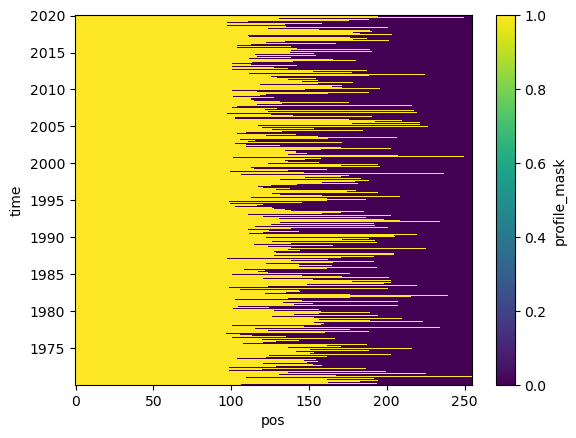

In [152]:

viking_argo_ds = xr.Dataset(
    {
        'temperature': (('z', 'time', 'pos'), dataset.votemper.values if deep_argo else dataset.votemper_depth_max.values ),
        'salinity': (('z', 'time', 'pos'),  dataset.vosaline.values if deep_argo else dataset.vosaline_depth_max.values),
        'profile_mask': (('time', 'pos'), ~np.isnan(dataset.votemper.isel(deptht = 0)).values if deep_argo else ~np.isnan(dataset.votemper_depth_max.isel(deptht = 0)).values),
    },
    coords = {
        'time': dataset.time_counter.values,
        'pos': dataset.profiles.values,
        'z': -dataset.deptht.values,
        'pressure': ('z',dataset.deptht.values),
        'lon': (('time', 'pos'), dataset.nav_lon.values),
        'lat': (('time', 'pos'), dataset.nav_lat.values),
        'time_1d': (('time','pos'), dataset.time_counter_1d.values),
    }
)
viking_argo_ds.profile_mask.plot()

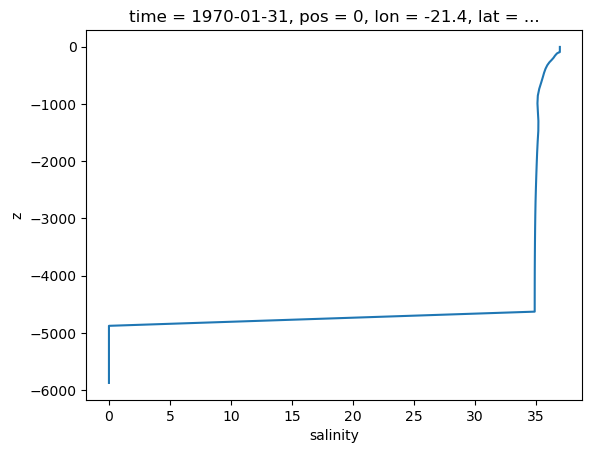

In [153]:
from gsw import CT_from_pt, rho

viking_argo_ds['ct']  = CT_from_pt(viking_argo_ds.salinity, viking_argo_ds.temperature)
viking_argo_ds['rho'] = rho(viking_argo_ds.salinity, viking_argo_ds.temperature, viking_argo_ds.pressure)

viking_argo_ds = viking_argo_ds.transpose('time', 'pos', 'z')
viking_argo_ds = viking_argo_ds.sortby('z')
viking_argo_ds.isel(time = 0, pos = 0).salinity.plot(y = 'z')

In [154]:
viking_argo_ds

<xarray.Dataset>
Dimensions:       (time: 609, pos: 255, z: 46)
Coordinates:
  * time          (time) datetime64[ns] 1970-01-31 1970-03-02 ... 2020-01-09
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 248 249 250 251 252 253 254
  * z             (z) float32 -5.875e+03 -5.625e+03 -5.375e+03 ... -9.454 -3.047
    pressure      (z) float32 5.875e+03 5.625e+03 5.375e+03 ... 9.454 3.047
    lon           (time, pos) float32 -21.4 -21.25 -21.05 -63.21 ... nan nan nan
    lat           (time, pos) float32 26.28 26.1 26.1 29.64 ... nan nan nan nan
    time_1d       (time, pos) datetime64[ns] 1970-01-20T12:00:00 ... NaT
Data variables:
    temperature   (time, pos, z) float32 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
    salinity      (time, pos, z) float32 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
    profile_mask  (time, pos) bool True True True True ... False False False
    ct            (time, pos, z) float64 0.01528 0.01528 0.01528 ... nan nan nan
    rho           (time, pos, z) float64 1.028e+03 1.027e+03 ... nan nan

In [155]:
viking_argo_ds.to_netcdf(dataset_path / dataset_sample_name / f'ds_{"deep_" if deep_argo else ""}argo_viking_KFS003-{suffix}.nc')

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:618: RuntimeWarning: invalid value encountered in cast
  int_num = np.asarray(num, dtype=np.int64)


In [156]:
print('Finished!')

Finished!


2025-03-06 11:32:50,501 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
2025-03-06 11:32:50,501 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
2025-03-06 11:32:50,503 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
2025-03-06 11:32:50,503 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
2025-03-06 11:32:50,507 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
2025-03-06 11:32:50,509 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
